In [3]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("readr")
install.packages("fixest")
install.packages("lmtest")
install.packages("sandwich")

library(dplyr)
library(ggplot2)
library(readr)
library(lmtest)
library(sandwich)
library(fixest)

# Leer datos
url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df <- read_csv(url)

Warning message:
"package 'dplyr' is in use and will not be installed"
Warning message:
"package 'ggplot2' is in use and will not be installed"
Warning message:
"package 'readr' is in use and will not be installed"
Warning message:
"package 'fixest' is in use and will not be installed"
Warning message:
"package 'lmtest' is in use and will not be installed"
Warning message:
"package 'sandwich' is in use and will not be installed"
Rows: 1617 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (10): stfips, year, _nfd, post, asmrs, pcinc, asmrh, cases, weight, copop

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
treated_fips <- unique(df$stfips)[1:10]
df <- df %>%
  mutate(TREAT = ifelse(stfips %in% treated_fips, 1, 0))

# Interacción TWFE
df <- df %>%
  mutate(treated = TREAT * post)

# Estimar TWFE usando fixest (con clustering por stfips)
model_twfe <- feols(asmrs ~ treated + pcinc + asmrh + cases | stfips + year, 
                    cluster = ~stfips, data = df)
summary(model_twfe)

OLS estimation, Dep. Var.: asmrs
Observations: 1,617
Fixed-effects: stfips: 49,  year: 33
Standard-errors: Clustered (stfips) 
           Estimate Std. Error  t value Pr(>|t|)    
treated   -8.618110   4.478546 -1.92431 0.060255 .  
pcinc     -0.000966   0.000373 -2.58806 0.012733 *  
asmrh      1.098864   0.588633  1.86681 0.068043 .  
cases   -162.305410 149.638801 -1.08465 0.283496    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 10.5     Adj. R2: 0.697778
             Within R2: 0.047469

In [6]:
df <- df %>%
  mutate(treat_year = ifelse(`_nfd` == 0, NA, `_nfd`),
         event_time = ifelse(is.na(treat_year), NA, year - treat_year))

In [7]:
names(df)[names(df) == "_nfd"] <- "nfd"

df <- df %>%
  mutate(treat_year = ifelse(nfd == 0, NA, nfd),
         event_time = ifelse(is.na(treat_year), NA, year - treat_year))

In [8]:
df$treat_year <- ifelse(df$nfd == 0, NA, df$nfd)
df$event_time <- ifelse(is.na(df$treat_year), NA, df$year - df$treat_year)

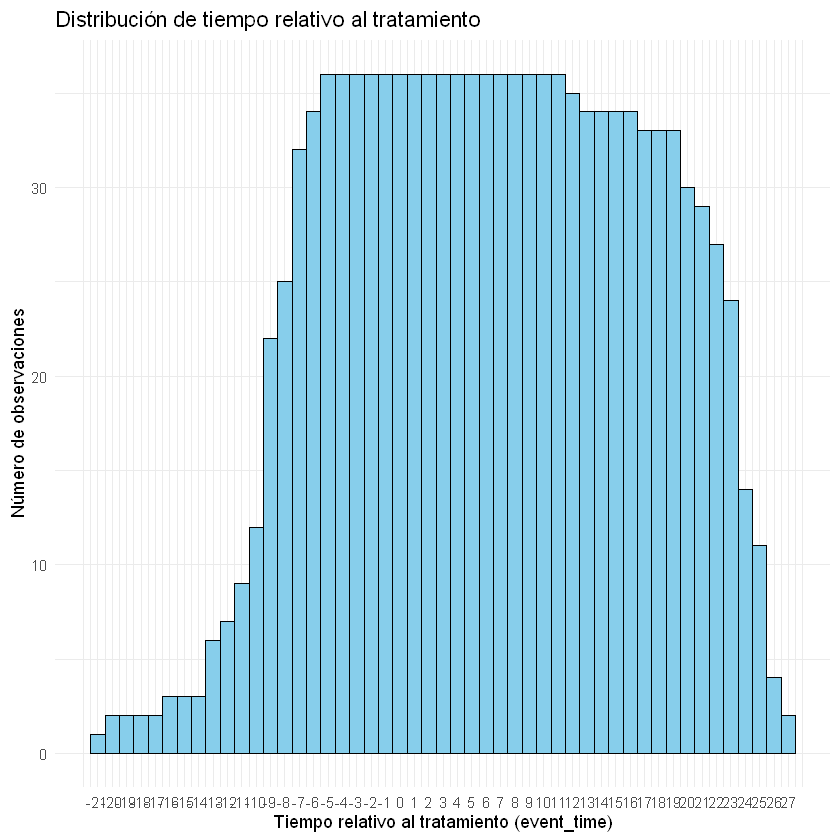

In [9]:
event_time_vals <- df$event_time[!is.na(df$event_time)]
ggplot(data.frame(event_time=event_time_vals), aes(x=event_time)) +
  geom_histogram(binwidth=1, fill="skyblue", color="black") +
  scale_x_continuous(breaks=min(event_time_vals):max(event_time_vals)) +
  labs(x="Tiempo relativo al tratamiento (event_time)",
       y="Número de observaciones",
       title="Distribución de tiempo relativo al tratamiento") +
  theme_minimal()

In [10]:
event_summary <- table(df$event_time)
print(event_summary)


-21 -20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2 
  1   2   2   2   2   3   3   3   6   7   9  12  22  25  32  34  36  36  36  36 
 -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18 
 36  36  36  36  36  36  36  36  36  36  36  36  36  35  34  34  34  34  33  33 
 19  20  21  22  23  24  25  26  27 
 33  30  29  27  24  14  11   4   2 


In [23]:
lower_bound <- -23
upper_bound <- 24

df$event_time_clipped <- pmax(pmin(df$event_time, upper_bound), lower_bound)

# Crear dummies
event_vars <- c()
for (k in -23:24) {
  if (k != -1) {
    col_name <- ifelse(k < 0, paste0("D_m", abs(k)), paste0("D_", k))
    df[[col_name]] <- ifelse(df$event_time_clipped == k, 1, 0)
    event_vars <- c(event_vars, col_name)
  }
}

In [24]:
formula <- as.formula(paste("asmrs ~", paste(event_vars, collapse=" + "), "+ pcinc + asmrh + cases | stfips + year"))
model_eventstudy <- feols(formula, cluster = ~stfips, data = df)

# Extraer coeficientes y errores estándar
coef_data <- data.frame(
  variable = event_vars,
  coef = coef(model_eventstudy)[event_vars],
  se = sqrt(diag(vcov(model_eventstudy)))[event_vars]
)

NOTE: 429 observations removed because of NA values (RHS: 429).

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


In [25]:
parse_k <- function(name) {
  if (grepl("m", name)) {
    return(-as.numeric(sub("D_m", "", name)))
  } else {
    return(as.numeric(sub("D_", "", name)))
  }
}
coef_data$k <- sapply(coef_data$variable, parse_k)
coef_data <- coef_data[order(coef_data$k), ]

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`)."


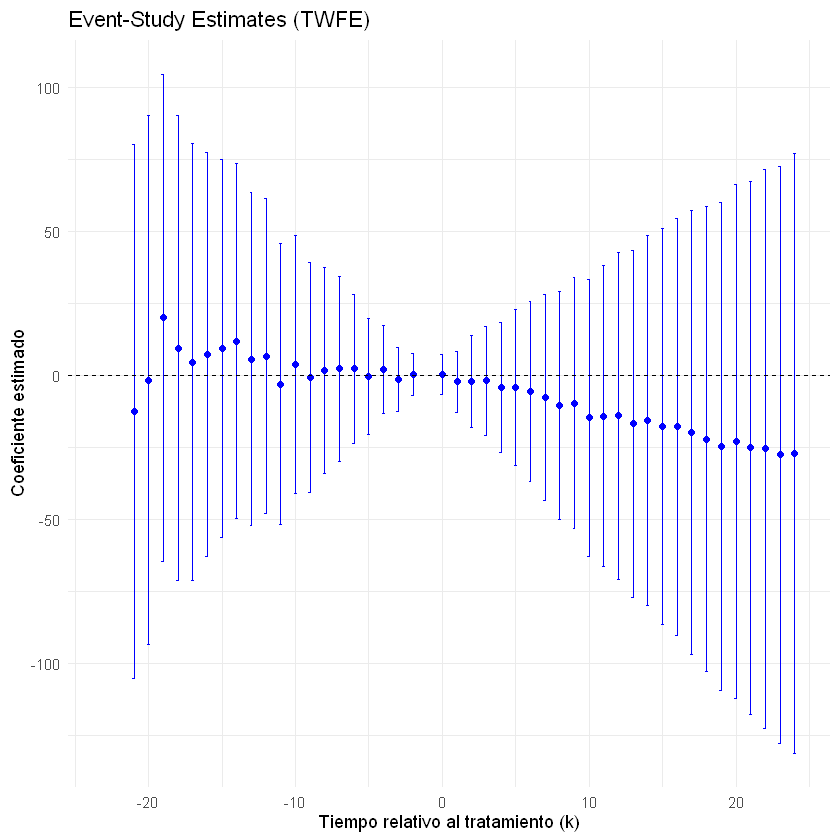

In [26]:
ggplot(coef_data, aes(x=k, y=coef)) +
  geom_point(color="blue") +
  geom_errorbar(aes(ymin=coef-1.96*se, ymax=coef+1.96*se), width=0.2, color="blue") +
  geom_hline(yintercept=0, linetype="dashed") +
  labs(x="Tiempo relativo al tratamiento (k)",
       y="Coeficiente estimado",
       title="Event-Study Estimates (TWFE)") +
  theme_minimal()

In [18]:
coef_data$ci_lower <- coef_data$coef - 1.96*coef_data$se
coef_data$ci_upper <- coef_data$coef + 1.96*coef_data$se

event_table <- coef_data[, c("k", "coef", "se", "ci_lower", "ci_upper")]
print(event_table)

      k        coef       se   ci_lower ci_upper
D_m5 -5 -4.86890103 4.199651 -13.100217 3.362415
D_m4 -4 -0.98471116 2.518309  -5.920597 3.951175
D_m3 -3 -3.39141109 2.870744  -9.018070 2.235248
D_m2 -2 -0.79705912 2.392389  -5.486141 3.892023
D_0   0  1.31651115 2.773958  -4.120446 6.753468
D_1   1 -0.20556492 3.295891  -6.665511 6.254381
D_2   2  0.93915812 4.405838  -7.696284 9.574601
D_3   3  2.08029679 3.283270  -4.354913 8.515507
D_4   4  0.80781793 3.488730  -6.030092 7.645728
D_5   5 -0.03800423 3.839933  -7.564274 7.488265
